In [13]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal

In [14]:
n = 10000
w = [0.3, 0.4, 0.3]

mu1 = [0,0]
mu2 = [50,50]
mu3 = [100,100]

Sigma1 = [[5,1],[1,5]]
Sigma2 = [[2,1],[1,2]]
Sigma3 = [[2,1],[1,2]]

choice = np.random.choice(3, size=n, p=w)

x1 = np.random.multivariate_normal(mu1, Sigma1, size=n)
x2 = np.random.multivariate_normal(mu2, Sigma2, size=n)
x3 = np.random.multivariate_normal(mu3, Sigma3, size=n)

x = np.choose(choice[:, None], [x1, x2, x3])

In [19]:
type(x)

numpy.ndarray

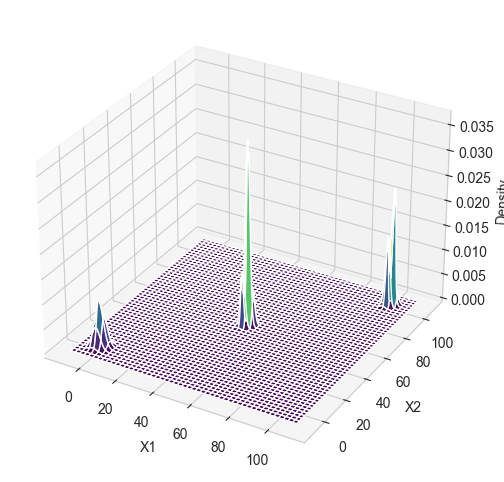

In [18]:
# grid covering all three
xaxis = np.linspace(-10,110,300)
yaxis = np.linspace(-10,110,300)

Xaxis, Yaxis = np.meshgrid(xaxis,yaxis)
pos = np.dstack((Xaxis,Yaxis))

# component densities
Z1 = multivariate_normal(mu1,Sigma1).pdf(pos)
Z2 = multivariate_normal(mu2,Sigma2).pdf(pos)
Z3 = multivariate_normal(mu3,Sigma3).pdf(pos)

# mixture density
Zaxis = w[0]*Z1 + w[1]*Z2 + w[2]*Z3

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(projection="3d")

ax.plot_surface(Xaxis,Yaxis,Zaxis,cmap="viridis")

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Density")

plt.show()

In [17]:
n, d = x.shape
L = 3 # number of components
w = np.array([0.3, 0.3, 0.4])
mu = x[np.random.choice(n, L, replace=False)]
Sigma = np.array([np.cov(x.T) for _ in range(L)])
loglik = 0
max_attempts = 100

for j in range(max_attempts):
    # ---- E STEP ----
    pdf = np.zeros((n,L))

    for l in range(L):
        pdf[:,l] = multivariate_normal(mu[l], Sigma[l]).pdf(x)

    weighted = w * pdf
    pi = weighted / weighted.sum(axis=1, keepdims=True)

    Nk = pi.sum(axis=0)

    # ---- M STEP ----
    w = Nk / n

    mu_new = (pi.T @ x) / Nk[:,None]

    Sigma_new = np.zeros((L,d,d))

    for l in range(L):
        diff = x - mu_new[l]
        Sigma_new[l] = (pi[:,l][:,None] * diff).T @ diff / Nk[l]

    loglik_new = np.sum(np.log(weighted.sum(axis=1)))

    print(f"{j} W {w}, \nmu {mu_new},\n Sigma \n{Sigma_new},\n loglik {loglik_new}")

    if abs(loglik - loglik_new) < 1e-5:
        break

    loglik = loglik_new
    mu = mu_new
    Sigma = Sigma_new

0 W [0.37587173 0.51206698 0.11206129], 
mu [[57.34441853 57.48152904]
 [51.76128046 51.13499741]
 [13.93986854 16.45785506]],
 Sigma 
[[[1344.7417704  1349.15484183]
  [1349.15484183 1356.09916172]]

 [[1417.0261411  1433.246164  ]
  [1433.246164   1452.64719953]]

 [[ 756.01918431  738.59367059]
  [ 738.59367059  725.26374106]]],
 loglik -76188.97962535813
1 W [0.37641526 0.50618402 0.11740071], 
mu [[58.83096943 58.95723344]
 [51.88231803 51.21882888]
 [10.34603976 12.91268384]],
 Sigma 
[[[1292.35204995 1293.82971942]
  [1293.82971942 1297.38081429]]

 [[1427.17019303 1449.69623457]
  [1449.69623457 1475.57540181]]

 [[ 500.31921194  482.0319021 ]
  [ 482.0319021   467.813463  ]]],
 loglik -70988.30546584618
2 W [0.38297549 0.49743103 0.11959348], 
mu [[60.29879689 60.43419465]
 [51.69773037 51.00020393]
 [ 6.79377692  9.37019826]],
 Sigma 
[[[1228.90621622 1227.62764835]
  [1227.62764835 1228.15513431]]

 [[1416.71446965 1443.21839708]
  [1443.21839708 1473.24433158]]

 [[ 357.010

In [3]:
from sklearn.mixture import GaussianMixture

X = x   # x already (n,2)

gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=0
)

gmm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",0


In [4]:
gmm.weights_

array([0.4079, 0.2992, 0.2929])

In [5]:
gmm.means_

array([[ 4.99894360e+01,  4.99637427e+01],
       [ 8.13715260e-02, -1.84070048e-02],
       [ 9.99735465e+01,  9.99987456e+01]])

In [6]:
gmm.covariances_

array([[[2.09960468, 1.04900943],
        [1.04900943, 2.05035036]],

       [[5.18056864, 0.99719509],
        [0.99719509, 4.95583923]],

       [[2.08046973, 1.06266438],
        [1.06266438, 2.0564396 ]]])

In [7]:
gmm.score(X)          # average log likelihood

-4.80946209552462